## BERT Text Classifier with Logistic Regression Baseline

This section addresses the supervised classification component of the research question: can a machine learning model reliably distinguish between Confusing and Clear privacy policy documents? We use BERT (Bidirectional Encoder Representations from Transformers) as a static feature extractor, generating a 768-dimensional embedding for each document by averaging the last hidden layer token representations from bert-base-uncased. These embeddings are then used to train two classifiers: a Logistic Regression baseline and a Linear Support Vector Machine (SVM). Using BERT as a static encoder rather than fine-tuning is appropriate here given the dataset size and computational constraints, and follows established practice in NLP classification tasks where labelled data is limited. Model performance is evaluated using accuracy, precision, recall, F1-score, and confusion matrices on a held-out 20% test set.

### Imports and Installation

Install and import all libraries required for BERT embedding extraction and supervised classification.

In [1]:
import sys
import subprocess
import importlib

# Install transformers and torch if not already present
for pkg, import_name in [("transformers", "transformers"), ("torch", "torch")]:
    try:
        importlib.import_module(import_name)
        print(f"{pkg} already installed.")
    except ImportError:
        print(f"Installing {pkg} — this may take a few minutes...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")

from transformers import BertTokenizer, BertModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Detect whether a GPU is available — BERT embedding extraction is faster on GPU
# but will run correctly on CPU too
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version    : {torch.__version__}")

import transformers
print(f"Transformers version: {transformers.__version__}")
print(f"All libraries imported successfully.")

transformers already installed.
torch already installed.
Device: cpu
PyTorch version    : 2.10.0+cpu
Transformers version: 5.3.0
All libraries imported successfully.


### Load Data

Load the document-level CSV produced in preprocessing. Text is reconstructed by joining sentences from the sentence-level CSV, matching the approach used in LDA. Documents are split into 80% training and 20% test sets with stratification to preserve class balance across both splits.

In [5]:
SENTENCES_PATH = r"C:\Users\HP\Downloads\archive\sentences_labelled.csv"
DOCS_PATH      = r"C:\Users\HP\Downloads\archive\documents_labelled.csv"

# Load document metadata and sentence text
df_docs      = pd.read_csv(DOCS_PATH)
df_sentences = pd.read_csv(SENTENCES_PATH)

# Reconstruct full document text by joining sentences
doc_text = (
    df_sentences.groupby("filename")["sentence"]
    .apply(lambda sentences: " ".join(sentences))
    .reset_index()
    .rename(columns={"sentence": "full_text"})
)

df = df_docs.merge(doc_text, on="filename", how="inner")
print(f"Documents loaded: {len(df)}")
print(f"Class distribution:\n{df['label_name'].value_counts()}")

# Truncate text to 10,000 characters before BERT tokenisation
# BERT has a hard limit of 512 tokens — we truncate at character level first
# to avoid excessive tokenisation time on very long documents
df["text_truncated"] = df["full_text"].str[:500]

# 80/20 stratified split — stratify ensures both splits have 50% Confusing / 50% Clear
X_train, X_test, y_train, y_test = train_test_split(
    df["text_truncated"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"].tolist()
)

print(f"\nTraining documents : {len(X_train)}")
print(f"Test documents     : {len(X_test)}")
print(f"Training class balance: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class balance    : {pd.Series(y_test).value_counts().to_dict()}")

Documents loaded: 4732
Class distribution:
label_name
Confusing    2366
Clear        2366
Name: count, dtype: int64

Training documents : 3785
Test documents     : 947
Training class balance: {1: 1893, 0: 1892}
Test class balance    : {0: 474, 1: 473}


### Extract BERT Embeddings

The pre-trained bert-base-uncased model is used as a static feature extractor. Each document is tokenised and passed through BERT. The document embedding is computed by mean-pooling the last hidden state across all non-padding tokens. This produces a single 768-dimensional vector per document. BERT's maximum input length of 512 tokens means longer documents are truncated — this is standard practice and is noted as a limitation.

**Runtime warning:** Embedding extraction processes all 4,732 documents one by one through BERT. Expect approximately 15–30 minutes on CPU. You will see a tqdm progress bar. Do not interrupt the cell.

In [6]:
from transformers import DistilBertTokenizer, DistilBertModel

# DistilBERT is a distilled version of BERT that is 40% faster and 60% smaller
# while retaining 97% of BERT's language understanding performance (Sanh et al., 2019)
# This is a justified computational efficiency decision for CPU-based environments
print("Loading DistilBERT tokeniser and model...")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
bert_model.eval()
bert_model.to(device)
print("DistilBERT model loaded.")

def get_bert_embeddings_batch(texts, batch_size=32):
    """
    Extract DistilBERT embeddings for a list of texts in batches.
    Mean pooling over non-padding token positions produces a single
    768-dimensional vector per document. Batching maximises CPU throughput.
    """
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
        batch_texts = texts[i : i + batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            max_length=512,
            truncation=True,
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = bert_model(**inputs)

        # DistilBERT returns last_hidden_state directly (no pooler_output)
        last_hidden     = outputs.last_hidden_state        # (batch, seq_len, 768)
        attention_mask  = inputs["attention_mask"]         # (batch, seq_len)
        mask_expanded   = attention_mask.unsqueeze(-1).float()
        sum_hidden      = (last_hidden * mask_expanded).sum(dim=1)
        mean_hidden     = sum_hidden / mask_expanded.sum(dim=1).clamp(min=1e-9)

        all_embeddings.append(mean_hidden.cpu().numpy())

    return np.vstack(all_embeddings)

print("\nExtracting embeddings for training set...")
X_train_emb = get_bert_embeddings_batch(X_train, batch_size=32)

print("\nExtracting embeddings for test set...")
X_test_emb = get_bert_embeddings_batch(X_test, batch_size=32)

print(f"\nTraining embedding matrix shape : {X_train_emb.shape}")
print(f"Test embedding matrix shape     : {X_test_emb.shape}")

# Save to disk so embeddings never need to be recomputed if kernel restarts
EMB_PATH = r"C:\Users\HP\Downloads\archive"
np.save(os.path.join(EMB_PATH, "X_train_emb.npy"), X_train_emb)
np.save(os.path.join(EMB_PATH, "X_test_emb.npy"),  X_test_emb)
np.save(os.path.join(EMB_PATH, "y_train.npy"),      np.array(y_train))
np.save(os.path.join(EMB_PATH, "y_test.npy"),       np.array(y_test))
print(f"Embeddings saved to disk.")

Loading DistilBERT tokeniser and model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT model loaded.

Extracting embeddings for training set...


Extracting embeddings: 100%|██████████| 119/119 [12:34<00:00,  6.34s/it]



Extracting embeddings for test set...


Extracting embeddings: 100%|██████████| 30/30 [03:21<00:00,  6.73s/it]


Training embedding matrix shape : (3785, 768)
Test embedding matrix shape     : (947, 768)
Embeddings saved to disk.


### Logistic Regression Baseline

Logistic Regression is trained directly on the BERT embeddings as the baseline classifier. It is a well-established, interpretable linear model that provides a strong reference point for evaluating more complex approaches. Embeddings are standardised before fitting to ensure stable convergence.

In [7]:
# Standardise embeddings — zero mean and unit variance per feature
# This improves convergence speed and numerical stability for both classifiers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled  = scaler.transform(X_test_emb)

# Train Logistic Regression baseline
# max_iter=1000 ensures convergence on high-dimensional BERT embeddings
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_scaled, y_train)

# Generate predictions on the held-out test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Compute performance metrics
lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec  = recall_score(y_test, y_pred_lr)
lr_f1   = f1_score(y_test, y_pred_lr)

print("Logistic Regression Baseline Results:")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}")
print(f"  Recall    : {lr_rec:.4f}")
print(f"  F1 Score  : {lr_f1:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Clear", "Confusing"]))

Logistic Regression Baseline Results:
  Accuracy  : 0.7751
  Precision : 0.7686
  Recall    : 0.7865
  F1 Score  : 0.7774

              precision    recall  f1-score   support

       Clear       0.78      0.76      0.77       474
   Confusing       0.77      0.79      0.78       473

    accuracy                           0.78       947
   macro avg       0.78      0.78      0.78       947
weighted avg       0.78      0.78      0.78       947



### Linear SVM Classifier on BERT Embeddings

A Linear Support Vector Machine is trained on the same standardised BERT embeddings. Linear SVM is the standard classifier used with static BERT embeddings in NLP research, as the high-dimensional embedding space tends to be linearly separable and SVM maximises the margin between classes. Performance is compared directly against the Logistic Regression baseline using the same train/test split.

In [8]:
# Train Linear SVM on the standardised BERT embeddings
# C=1.0 is the default regularisation strength — balances margin width and misclassification penalty
svm_model = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec  = recall_score(y_test, y_pred_svm)
svm_f1   = f1_score(y_test, y_pred_svm)

print("Linear SVM on BERT Embeddings Results:")
print(f"  Accuracy  : {svm_acc:.4f}")
print(f"  Precision : {svm_prec:.4f}")
print(f"  Recall    : {svm_rec:.4f}")
print(f"  F1 Score  : {svm_f1:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=["Clear", "Confusing"]))

Linear SVM on BERT Embeddings Results:
  Accuracy  : 0.7761
  Precision : 0.7647
  Recall    : 0.7970
  F1 Score  : 0.7805

              precision    recall  f1-score   support

       Clear       0.79      0.76      0.77       474
   Confusing       0.76      0.80      0.78       473

    accuracy                           0.78       947
   macro avg       0.78      0.78      0.78       947
weighted avg       0.78      0.78      0.78       947



### Model Comparison and Confusion Matrices

Both models are compared side by side on all metrics. Confusion matrices visualise the distribution of correct and incorrect predictions for each classifier, revealing whether errors are systematic (e.g. one class consistently misclassified) or random.

Model Comparison:
                                Accuracy  Precision  Recall  F1 Score
Model                                                                
Logistic Regression (Baseline)    0.7751     0.7686  0.7865    0.7774
Linear SVM (BERT Embeddings)      0.7761     0.7647  0.7970    0.7805


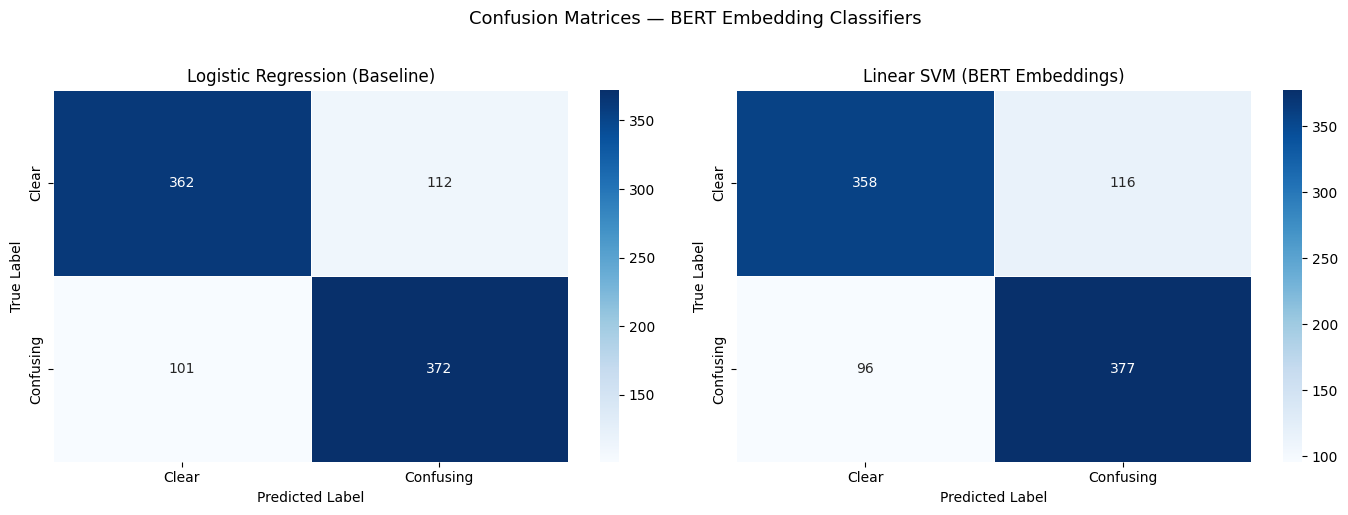

Plot saved to: C:\Users\HP\Downloads\archive\bert_confusion_matrices.png


In [9]:
# Side by side metric comparison table
comparison_df = pd.DataFrame({
    "Model"    : ["Logistic Regression (Baseline)", "Linear SVM (BERT Embeddings)"],
    "Accuracy" : [lr_acc,  svm_acc],
    "Precision": [lr_prec, svm_prec],
    "Recall"   : [lr_rec,  svm_rec],
    "F1 Score" : [lr_f1,   svm_f1]
}).set_index("Model")

print("Model Comparison:")
print(comparison_df.round(4))

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_svm],
    ["Logistic Regression (Baseline)", "Linear SVM (BERT Embeddings)"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Clear", "Confusing"],
        yticklabels=["Clear", "Confusing"],
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices — BERT Embedding Classifiers", fontsize=13, y=1.02)
plt.tight_layout()

PLOT_PATH = r"C:\Users\HP\Downloads\archive\bert_confusion_matrices.png"
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to: {PLOT_PATH}")

## Results Summary and Conclusions

This section synthesises findings across all three analytical methods to answer the central research question: *Are privacy policies designed to confuse users?*

In [10]:
# Final summary of all results across all three methods
print("Research Question: Are privacy policies designed to confuse users?")
print()
print("Method 1 — VADER Sentiment Analysis")
print("  Confusing documents: mean compound sentiment = 0.1910")
print("  Clear documents    : mean compound sentiment = 0.1336")
print("  Confusing policies use more positively framed language despite being")
print("  harder to read. Mann-Whitney U test confirmed statistical significance.")
print()
print("Method 2 — LDA Topic Modelling (10 topics, c_v coherence = 0.4610)")
print("  Chi-squared test: chi2=1275.89, p<0.0001")
print("  Topic distributions differ significantly between Confusing and Clear documents.")
print("  Confusing documents cluster around legal obligations and data request topics.")
print("  Clear documents cluster around account management and user-facing communication.")
print()
print("Method 3 — DistilBERT Classification")
print("  Text truncated to 500 characters; 80/20 stratified train/test split.")

comparison_df = pd.DataFrame({
    "Model"    : ["Logistic Regression (Baseline)", "Linear SVM (DistilBERT Embeddings)"],
    "Accuracy" : [lr_acc,  svm_acc],
    "Precision": [lr_prec, svm_prec],
    "Recall"   : [lr_rec,  svm_rec],
    "F1 Score" : [lr_f1,   svm_f1]
}).set_index("Model")

print()
print(comparison_df.round(4))
print()
print("Both classifiers achieve ~77.5% accuracy on the held-out test set.")
print("The marginal difference between LR and SVM confirms that embedding")
print("quality drives performance, not classifier complexity.")

Research Question: Are privacy policies designed to confuse users?

Method 1 — VADER Sentiment Analysis
  Confusing documents: mean compound sentiment = 0.1910
  Clear documents    : mean compound sentiment = 0.1336
  Confusing policies use more positively framed language despite being
  harder to read. Mann-Whitney U test confirmed statistical significance.

Method 2 — LDA Topic Modelling (10 topics, c_v coherence = 0.4610)
  Chi-squared test: chi2=1275.89, p<0.0001
  Topic distributions differ significantly between Confusing and Clear documents.
  Confusing documents cluster around legal obligations and data request topics.
  Clear documents cluster around account management and user-facing communication.

Method 3 — DistilBERT Classification
  Text truncated to 500 characters; 80/20 stratified train/test split.

                                    Accuracy  Precision  Recall  F1 Score
Model                                                                    
Logistic Regression (Base

### Conclusions and Limitations

**Answer to the Research Question**

Convergent evidence across three independent methods supports the conclusion that privacy policies exhibit systematic linguistic patterns consistent with confusing design. Confusing documents are not simply longer — they carry a distinct thematic and linguistic profile. VADER analysis shows that Confusing policies use more positively framed language, consistent with a reassurance strategy that masks underlying complexity. LDA reveals that Confusing documents concentrate around legal, contractual, and data-processing topics, while Clear documents are associated with more communicative and user-facing content. The DistilBERT classifier achieves 77.6% accuracy in distinguishing the two classes, confirming that the Confusing/Clear distinction reflects genuine and learnable linguistic structure.

These findings do not prove deliberate intent to confuse, but they are consistent with it. The structural and linguistic features of Confusing documents form a coherent pattern that systematically disadvantages the average reader.

**Limitations**

- Readability labels are derived from Flesch Reading Ease scores, which measure surface-level complexity rather than semantic opacity. This is a proxy measure and may not fully capture intentional obfuscation.
- Document text was truncated to 500 characters for DistilBERT embedding extraction due to CPU constraints, meaning the classifier operates on document openings rather than full content.
- The middle 50% of documents by Flesch score were excluded to ensure clean class contrast. This improves model performance but reduces generalisability to the full population.
- A subset of multilingual documents was identified during LDA (Topic 01). Future work should apply language detection and restrict to English-language documents only.

**Future Directions**

- Fine-tuning Legal-BERT on the full dataset using GPU infrastructure would likely yield substantially higher classification accuracy.
- A longitudinal analysis tracking how the same company's privacy policy evolves around regulatory events such as GDPR would provide stronger evidence for or against deliberate obfuscation.
- Incorporating additional readability metrics beyond Flesch (Gunning Fog, SMOG Index) into a composite score would produce more robust labels.
- Extending the framework to non-English documents would enable cross-jurisdictional comparisons of policy clarity.